# Part 2: Train + Validate — Sarah's First Logistic Regression
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Wednesday — Training the Model

Yesterday Sarah built the preprocessor. Today she chains it with a logistic regression and trains her first model.

She has three questions to answer before walking into Marcus's office on Friday:

1. **Does the model learn anything useful?** (or is it no better than guessing "stayed" for everyone?)
2. **Which features actually matter?** (Marcus will ask — and Sarah needs to know.)
3. **Is the accuracy number trustworthy?** (One split gives one number. Is that number stable?)

**By the end of this notebook you will be able to:**
- Chain preprocessing + model into a single sklearn `Pipeline`
- Train with one `.fit()` call and predict with one `.predict()` call
- Read the trained coefficients to explain which features drive churn predictions
- Use 5-fold cross-validation to get a stable accuracy estimate

In [10]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — including sklearn.linear_model.LogisticRegression")

✅ Libraries loaded — including sklearn.linear_model.LogisticRegression


## Step 1 — Rebuild the dataset split and preprocessor

**Why re-run this here?** Each notebook is self-contained — you should be able to run it from top to bottom without needing any other notebook to have run first. This is good practice in data science: reproducibility means no hidden state left over from a previous session.

**Why split into train and test sets?** The test set is data the model never sees during training. Reporting accuracy on it gives an honest estimate of how the model performs on *new* customers — which is the real question Sarah needs to answer for Marcus. Evaluating on training data would be like letting students practise on the exact exam questions: the score would look great but mean nothing.

**Why `stratify=y`?** Our dataset has ~12% churners and ~88% non-churners. Without stratification, the random split could accidentally put 20% churners in the test set and only 5% in training, distorting what the model learns. `stratify=y` ensures both halves have the same churn rate as the full dataset.

In [11]:
# Load and split
df = pd.read_csv("data/northstar_churn.csv")
y  = df["churned"]
X  = df.drop(columns=["customer_id", "churned"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

numeric_features = [
    "age", "tenure_months", "num_purchases_quarter",
    "avg_monthly_spend_gbp", "returns_per_purchase",
    "last_login_days_ago", "avg_review_polarity",
    "support_tickets_quarter",
]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

print(f"Training set: {len(X_train):,} customers")
print(f"Test set:     {len(X_test):,} customers")
print("Preprocessor ready (median impute + standard scale | mode impute + one-hot)")

Training set: 8,000 customers
Test set:     2,000 customers
Preprocessor ready (median impute + standard scale | mode impute + one-hot)


## Step 2 — Build the full pipeline: preprocessor + model

**Why wrap everything in one `Pipeline`?**

Without a Pipeline, you would have to manage each transformation manually:

```python
# Without Pipeline — easy to get wrong:
X_train_transformed = preprocessor.fit_transform(X_train)   # fits AND transforms
X_test_transformed  = preprocessor.transform(X_test)        # transforms only ← easy to forget this distinction

model.fit(X_train_transformed, y_train)
predictions = model.predict(X_test_transformed)
```

The danger: if you accidentally call `.fit_transform()` on the test set, the scaler learns the test data's statistics — that's **data leakage**. The model gets an unfair peek at test-time information, and your accuracy estimate is optimistically wrong.

With a Pipeline, this mistake is impossible. One object, one `.fit()`, one `.predict()`. Sklearn handles the correct sequencing automatically — and the pipeline is reusable: hand it to anyone and it works correctly out of the box.

**What model are we using?** See the logistic regression explainer below before looking at the code.

### What is logistic regression?

**Logistic regression** is a classification algorithm that answers: *"What is the probability this customer will churn?"*

Despite the word "regression," it's a classifier. Here's how it works in three steps:

**1. Linear combination** — multiply each feature by a learned weight and sum them up:

$$z = \beta_0 + \beta_1 \times \text{tenure} + \beta_2 \times \text{returns} + \beta_3 \times \text{subscription\_tier} + \ldots$$

**2. Sigmoid function** — squash `z` into a probability between 0 and 1:

$$P(\text{churn}) = \frac{1}{1 + e^{-z}}$$

> When `z` is large and positive → P(churn) → 1.0 (almost certain to churn)  
> When `z` is large and negative → P(churn) → 0.0 (almost certain to stay)  
> When `z` = 0 → P(churn) = 0.5 (coin flip)

**3. Classification** — apply a threshold to turn the probability into a class label:

| Probability | Predicted class |
|---|---|
| P(churn) ≥ 0.5 | **Churned** |
| P(churn) < 0.5 | **Stayed** |

(The 0.5 threshold is the default — we can move it. That's Friday's question.)

---

**Why logistic regression as our first model?**

| Reason | Why it matters here |
|---|---|
| **Interpretable** | Each feature gets one coefficient — we can see exactly which features drive predictions |
| **Fast** | Fits in seconds on thousands of rows |
| **Good baseline** | If a fancier model can't beat it, something is wrong |
| **Calibrated probabilities** | The output probabilities are meaningful, not just relative scores |

> **Back to our scenario:** Marcus will ask *"why does the model predict churn for this customer?"* Logistic regression lets Sarah point at the coefficient chart and say *"because the return rate is high and tenure is short."* A black-box model can't do that.

In [12]:
# Logistic regression — most interpretable classifier; right starting baseline.
# max_iter raised because the default sometimes warns about non-convergence on this dataset.
model = LogisticRegression(max_iter=1000, random_state=42)

# Wrap preprocessor + model in one Pipeline
full_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", model),
])

print("✅ Full pipeline built.")
print()
print("Steps in order:")
for name, step in full_pipeline.steps:
    print(f"  · {name:8s}  →  {step.__class__.__name__}")

✅ Full pipeline built.

Steps in order:
  · prep      →  ColumnTransformer
  · model     →  LogisticRegression


## ⏸️ Pause and Predict

Before we train, predict for yourself: which features will get the strongest POSITIVE coefficients (push toward 'churned'), and which will get the strongest NEGATIVE coefficients (push toward 'stayed')?

From **Monday's EDA** we confirmed: short tenure → high churn (we saw this in the tenure-bucket chart).

Beyond that, Sarah forms these **working hypotheses** from domain knowledge — not yet confirmed by data:

- **Premium subscribers → likely lower churn** *(they've committed to a paid tier)*
- **High return rate → probably high churn** *(returning products signals unhappiness)*
- **Many support tickets → probably high churn** *(friction and frustration with the product)*
- **Negative review polarity → probably high churn** *(dissatisfied customers are more likely to leave)*

These are hypotheses. The model's coefficients in Step 4 will tell us which ones actually hold up.

*Write your top-3 positive and top-3 negative predictions here before running Step 4:*

> *Sample expected:*
> - **Positive (push toward churn):** returns_per_purchase, support_tickets_quarter, last_login_days_ago
> - **Negative (push toward stay):** tenure_months, subscription_tier_premium, avg_review_polarity

## Step 3 — Fit on training data

**Why fit only on the training set?** The call `full_pipeline.fit(X_train, y_train)` is where learning happens. Critically, *only `X_train` and `y_train` are used here* — the test set stays untouched until evaluation.

This separation is fundamental: the test set simulates customers the model has never seen. If training touches test data in any way — even just to compute a mean for scaling — we're giving the model an unfair advantage. The resulting accuracy would be optimistically misleading.

Here's what "fitting" means for each layer of the pipeline:

| Layer | What it learns |
|---|---|
| **Imputer** | Median / mode values to fill missing data |
| **Scaler** | Mean and standard deviation of each numeric feature |
| **OneHotEncoder** | The complete list of valid categories for each categorical column |
| **LogisticRegression** | The coefficient (β) for each feature |

All of this happens in a single line.

In [13]:
full_pipeline.fit(X_train, y_train)

print("✅ Pipeline fitted.")
print()
print(f"Training accuracy:   {full_pipeline.score(X_train, y_train):.3f}")
print(f"Test accuracy:       {full_pipeline.score(X_test,  y_test):.3f}")
print()
print(f"Baseline (always 'stayed'): {1 - y_test.mean():.3f}  ← anything better than this is learning something.")

✅ Pipeline fitted.

Training accuracy:   0.883
Test accuracy:       0.878

Baseline (always 'stayed'): 0.881  ← anything better than this is learning something.


**<span style="color:green">[Opus 4.8]</span> Exactly where the `0.881` baseline comes from:**

`y_test` is the **2,000-row test set** (the 20% held out), *not* the full 10,000. `y_test.mean()` is the **fraction of churners** in that test set, so `1 - y_test.mean()` is the **fraction who stayed** — which is precisely the accuracy you'd get by **guessing "stayed" for every test customer** (the majority-class / "no-model" classifier).

| | Stayed (0) | Churned (1) | `1 - mean()` |
|---|---|---|---|
| Full data (10,000) | 8,804 | 1,196 | 0.8804 |
| **Test set (2,000)** | **1,761** | **239** | **1761/2000 = 0.8805 → 0.881** |

So `0.881 = 1,761 / 2,000` (test set only). It lands almost exactly on the full-data rate (0.8804) **because the split used `stratify=y`**, which forces the test set to mirror the original 88/12 class balance — without it, the baseline could drift to 0.87 or 0.89.

⚠️ **Read the numbers together:** test accuracy **0.878** is *below* this baseline, and CV mean **0.883** is barely above it. Beating the baseline is what "learning something" *would* mean — but on this imbalanced data the model essentially **ties** it. That's not a broken model; it's that **accuracy is the wrong metric here**. Notebook `04_metrics_threshold.ipynb` ("The Accuracy is a Lie") switches to precision / recall / F1 to judge it properly.

*<span style="color:green">[Opus 4.8] — end of note</span>*

### 💡 What you should notice

- **Test accuracy (0.878) is actually slightly *below* the baseline (0.881).** This can happen with a single random split — the 2,000 customers who ended up in the test set may have been slightly easier or harder than average. The cross-validation mean (0.883) sits just above baseline, which is the more reliable number. Either way, on an imbalanced dataset the gap is tiny and not meaningful. We need a better metric than accuracy to judge this model. That's tomorrow's notebook.
- **Training accuracy and test accuracy are similar.** That's a sign the model is NOT overfitting. (If training was much higher than test, we'd worry.)
- **The next obvious question is "WHY does the model predict what it predicts?"** Logistic regression makes this answerable — let's inspect the coefficients.

## Step 4 — Coefficient inspection

Each feature gets one coefficient (`β`). Sign tells you direction; magnitude tells you strength (because features are scaled to comparable units after preprocessing).

> **Positive β** — higher feature value → higher predicted probability of churn.
> **Negative β** — higher feature value → lower predicted probability of churn.

Top features ranked by absolute coefficient size:
                  feature  coefficient
subscription_tier_premium    -0.791906
     returns_per_purchase     0.571233
            tenure_months    -0.533668
           region_Ireland    -0.448147
  subscription_tier_basic    -0.406700
      avg_review_polarity    -0.347717
             region_North    -0.346542
            region_London    -0.330774
   subscription_tier_free    -0.327932
      last_login_days_ago     0.209059


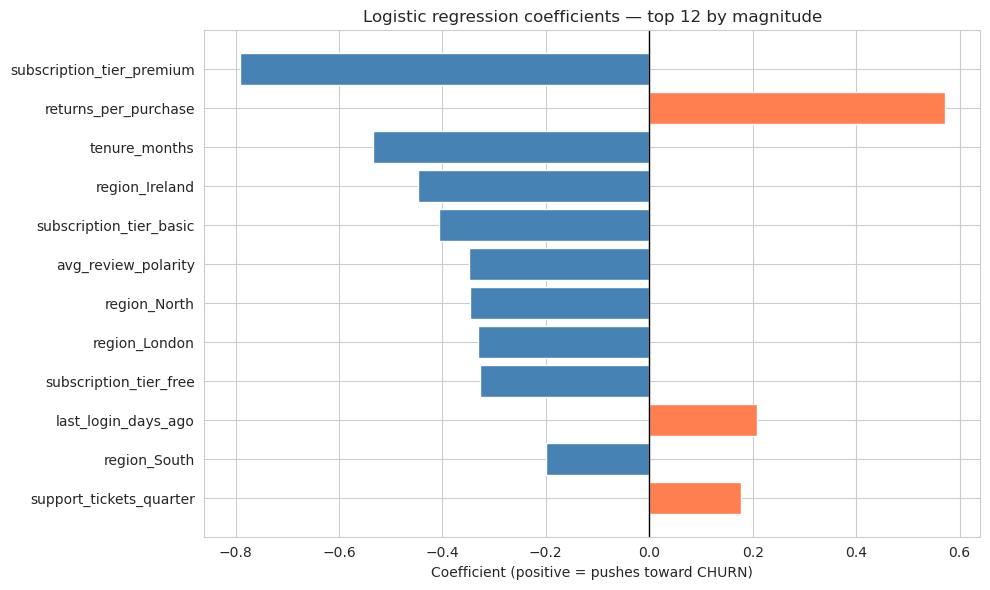

In [14]:
# Grab the trained logistic regression model and the feature names
feature_names = full_pipeline.named_steps["prep"].get_feature_names_out()
coefs         = full_pipeline.named_steps["model"].coef_[0]

# Build a tidy dataframe sorted by absolute strength
coef_df = pd.DataFrame({
    "feature":     [name.split("__")[-1] for name in feature_names],
    "coefficient": coefs,
    "abs_coef":    np.abs(coefs),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("Top features ranked by absolute coefficient size:")
print(coef_df[["feature", "coefficient"]].head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = coef_df.head(12).iloc[::-1]
colors  = ["coral" if c > 0 else "steelblue" for c in plot_df["coefficient"]]
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Coefficient (positive = pushes toward CHURN)")
ax.set_title("Logistic regression coefficients — top 12 by magnitude")
plt.tight_layout()
plt.show()

### 💡 What you should notice

- **`returns_per_purchase` has the strongest positive coefficient.** High return rate → higher predicted churn probability. Matches intuition: people who return a lot are unhappy.
- **`avg_review_polarity` has a strong negative coefficient.** Higher (more positive) reviews → lower predicted churn. Also matches intuition.
- **`tenure_months` is negative.** Longer-tenured customers churn less. Matches yesterday's tenure-bucket chart.
- **`subscription_tier_premium` is negative**, while `_basic` and `_free` are positive or near zero — premium customers churn less.

**Back to our scenario:**
> Sarah can now answer Marcus's question "why does the model predict what it predicts?" — pointing at this chart and saying "returns and reviews are the strongest signals, followed by tenure and subscription tier." That's interpretability.

## Step 5 — 5-fold cross-validation

**Why not just use the single 80/20 split accuracy?**

The split gave us one number: 0.878. But that number depends on *which* 2,000 customers happened to end up in the test set — a matter of chance (controlled by `random_state=42`). A different random seed gives a slightly different number. We don't know if we got lucky or unlucky.

Cross-validation repeats the train-and-evaluate cycle on 5 different portions of the data:

```
Fold 1: train on folds 2–5, evaluate on fold 1  → score
Fold 2: train on folds 1,3–5, evaluate on fold 2 → score
Fold 3: ...
Fold 4: ...
Fold 5: train on folds 1–4, evaluate on fold 5  → score
```

The **mean** tells us the expected performance; the **standard deviation** tells us how stable that estimate is. A small std means the model performs consistently regardless of which customers it's tested on — that's exactly the reassurance Sarah needs before walking into Marcus's office.

Note: `cross_val_score` re-fits the full pipeline (preprocessing + model) for each fold. The preprocessor re-learns its parameters on each fold's training data, keeping the evaluation honest.

**<span style="color:green">[Opus 4.8]</span> What "5-fold" mechanically does, and what `random_state=42` is:**

Cross-validation runs on the **8,000 training rows only** (the 2,000-row test set stays locked away). The steps:

1. Cut the 8,000 rows into **5 equal folds** of ~1,600 each.
2. Run **5 rounds** — each round trains on 4 folds (6,400 rows) and validates on the 1 held-out fold (1,600 rows):

```
        fold1   fold2   fold3   fold4   fold5
Round1 [ VAL ] [train] [train] [train] [train] → 0.882
Round2 [train] [ VAL ] [train] [train] [train] → 0.884
Round3 [train] [train] [ VAL ] [train] [train] → 0.882
Round4 [train] [train] [train] [ VAL ] [train] → 0.881
Round5 [train] [train] [train] [train] [ VAL ] → 0.886
```

3. **Every fold is the validation set exactly once** → 5 independent scores. Report the **mean** (expected performance) and **std** (stability — small std = consistent no matter which slice is tested).

**Why this beats the single 80/20 split:** that split gave *one* number that depended on *which* 2,000 customers happened to land in the test set. CV averages over 5 different validation slices, so the estimate doesn't hinge on one lucky/unlucky draw. (Note: `cross_val_score` re-fits the *entire* pipeline each round, so the scaler/imputer re-learn on that round's 6,400 rows only — no leakage into the validation fold.)

---

**`random_state=42` — what it is:**

- `shuffle=True` randomly shuffles the rows **before** cutting them into folds (otherwise fold 1 would just be the first 1,600 rows in file order, which might be sorted/biased).
- `random_state` is the **seed** for that shuffle's random number generator. Fixing it to an integer means *same shuffle → same folds → same scores* on every run. **Reproducibility, nothing more.**
- **`42` is arbitrary** — a programmer in-joke (the "answer to everything" from *The Hitchhiker's Guide to the Galaxy*). Any integer works; only *fixing* it matters. Changing it gives slightly different folds and slightly different numbers (wobbling within the ±0.002 std here) — it does **not** make the model better.

It appears in **three** places in this notebook, each taming a *different* source of randomness — they're independent and don't need to share the same value:

| Location | What it makes reproducible |
|---|---|
| `train_test_split(random_state=42)` | which 2,000 rows become the test set |
| `LogisticRegression(random_state=42)` | the solver's internal randomness during fitting |
| `StratifiedKFold(random_state=42)` | the fold shuffling above |

*<span style="color:green">[Opus 4.8] — end of note</span>*

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    full_pipeline,
    X_train, y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)

print(f"5-fold CV accuracy scores: {[f'{s:.3f}' for s in cv_scores]}")
print()
print(f"Mean: {cv_scores.mean():.3f}")
print(f"Std:  {cv_scores.std():.3f}")
print()
print(f"Stable estimate: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(f"Versus baseline (always 'stayed'): {1 - y_train.mean():.3f}")
print()
print("→ Cross-validated accuracy is a much more honest number than the single split.")
print("→ But we already know accuracy isn't the right metric. Tomorrow: precision and recall.")

5-fold CV accuracy scores: ['0.882', '0.884', '0.882', '0.881', '0.886']

Mean: 0.883
Std:  0.002

Stable estimate: 0.883 ± 0.002

Versus baseline (always 'stayed'): 0.880

→ Cross-validated accuracy is a much more honest number than the single split.
→ But we already know accuracy isn't the right metric. Tomorrow: precision and recall.


## ✅ Section Summary

| What we did | Result |
|---|---|
| **Built the full pipeline** | One sklearn `Pipeline` — preprocess + LogisticRegression — fits and predicts in one call |
| **Fitted on training data** | The line where the model actually learns its parameters |
| **Inspected coefficients** | `returns_per_purchase` (+), `avg_review_polarity` (−), `tenure_months` (−) drive predictions — all match intuition |
| **5-fold CV accuracy** | Stable around `~88-89%` — but accuracy ≈ baseline because the data is imbalanced |

**Key insight for our scenario:**
> Sarah has a trained model and can explain WHY it predicts what it predicts (via the coefficients). But the accuracy number is suspicious — it's barely above baseline. Tomorrow she has to look at the confusion matrix to see whether the model is actually *catching* churners — or just predicting "stayed" most of the time.

---
**Up next → Part 3:** Thursday — confusion matrix, precision, recall, F1, and the business decision about where to set the classification threshold.
Open `04_metrics_threshold.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Why `stratify=y` matters in CV too

`StratifiedKFold` ensures each fold has roughly the same churn rate as the full dataset. Without stratification, you could get unlucky — one fold with 5% churn rate and another with 18%, making accuracy comparisons across folds meaningless.

You can verify by checking each fold's distribution:

In [16]:
for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    fold_churn_rate = y_train.iloc[val_idx].mean()
    print(f"Fold {i+1} validation churn rate: {fold_churn_rate:.1%}")
print()
print("→ All within 1% of each other. Stratification is doing its job.")

Fold 1 validation churn rate: 11.9%
Fold 2 validation churn rate: 11.9%
Fold 3 validation churn rate: 11.9%
Fold 4 validation churn rate: 12.0%
Fold 5 validation churn rate: 12.0%

→ All within 1% of each other. Stratification is doing its job.


## Extension 2 — Regularization with the `C` parameter

`LogisticRegression(C=1.0)` is the default. `C` is the *inverse* of regularization strength — smaller `C` = stronger regularization = simpler model with smaller coefficients = less variance, more bias.

Let's compare three values.

In [17]:
for C_val in [0.01, 1.0, 100.0]:
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", LogisticRegression(C=C_val, max_iter=1000, random_state=42)),
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy",
                             n_jobs=-1).mean()
    coefs = pipe.fit(X_train, y_train).named_steps["model"].coef_[0]
    print(f"C = {C_val:>6}  CV acc = {score:.3f}  Max |coef| = {np.abs(coefs).max():.3f}")

C =   0.01  CV acc = 0.881  Max |coef| = 0.511
C =    1.0  CV acc = 0.883  Max |coef| = 0.792
C =  100.0  CV acc = 0.883  Max |coef| = 0.817


### 💡 What this tells us

- **Strong regularization (C=0.01)** — coefficients are shrunk toward zero. The model is simpler. Sometimes this generalises better on small or noisy datasets.
- **Weak regularization (C=100)** — coefficients are bigger. The model fits training data more aggressively. Risk of overfitting on more complex data, but on our clean simulated dataset the effect is small.
- **For this dataset**, all three values give similar CV accuracy. Regularization mostly matters in higher-dimensional or noisier real-world problems.

**<span style="color:green">[Opus 4.8]</span> Deeper detail on `C` — what regularization is, and why the coefficients shrink:**

**Regularization** means adding a penalty on coefficient *size* to what the model minimizes, so it doesn't fit the training data too aggressively (overfit). Plain logistic regression minimizes only the prediction error (log-loss); regularized LR minimizes:

$$\underbrace{C \cdot (\text{log-loss on training data})}_{\text{fit the data}} \;+\; \underbrace{\tfrac{1}{2}\lVert \beta \rVert^2}_{\text{keep coefficients small}}$$

`C` is the weight on the **data-fit** term, which is why it acts as the **inverse** of regularization strength (`C = 1/λ`):

| `C` | Penalty influence | Coefficients | Bias / Variance |
|---|---|---|---|
| **small** (0.01) | strong | shrunk toward 0 → simpler model | ↑ bias, ↓ variance |
| **default** (1.0) | balanced | moderate | balanced |
| **large** (100) | weak | free to grow → fits training data hard | ↓ bias, ↑ variance (overfit risk) |

**Reading the output above — the `Max |coef|` column is the story:** as `C` rises the penalty loosens and the largest coefficient grows `0.511 → 0.792 → 0.817`. That's the direct, visible effect of `C`. **CV accuracy barely moves** (`0.881 → 0.883`) only because this is a clean, low-dimensional simulated dataset (17 features, strong signal) — so don't over-generalize the "effect is small" takeaway; on **noisy, high-dimensional real data**, tuning `C` is often decisive.

**Three things worth knowing:**
1. **Regularization is *why* scaling matters.** The penalty `‖β‖²` treats every coefficient equally, so an unscaled feature in large raw units would be unfairly penalized. `StandardScaler` (notebook 02) puts all features on comparable footing first — regularized LR essentially **requires** scaled features.
2. **L2 vs L1.** Default `penalty="l2"` (Ridge: shrinks smoothly, rarely exactly 0). `penalty="l1"` (Lasso) can drive weak coefficients to *exactly* 0 → automatic feature selection. `C` sets the *strength* of whichever penalty you choose.
3. **You don't guess `C`** — you tune it with cross-validation (`GridSearchCV` / `LogisticRegressionCV`), the same CV machinery from Step 5.

*<span style="color:green">[Opus 4.8] — end of note</span>*

## Extension 3 — Comparing logistic regression to a baseline classifier

How much value is the model really adding? Compare to a `DummyClassifier` that just predicts the majority class.

In [18]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy_score = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="accuracy",
                              n_jobs=-1).mean()

print(f"Dummy classifier (always 'stayed'): {dummy_score:.3f}")
print(f"Our logistic regression:              {cv_scores.mean():.3f}")
print(f"Lift from logistic regression:        +{cv_scores.mean() - dummy_score:.3f}")
print()
print("On accuracy alone the lift is tiny — about 1 percentage point. Because the data is imbalanced,")
print("ANY classifier that learns SOMETHING will score similar to baseline. We need real metrics now.")

Dummy classifier (always 'stayed'): 0.880
Our logistic regression:              0.883
Lift from logistic regression:        +0.003

On accuracy alone the lift is tiny — about 1 percentage point. Because the data is imbalanced,
ANY classifier that learns SOMETHING will score similar to baseline. We need real metrics now.


**<span style="color:green">[Opus 4.8]</span> What `DummyClassifier` is, why it's used here, and what the lift really means:**

**`DummyClassifier` is sklearn's "no-skill" reference model** — an estimator that predicts using a trivial fixed rule and **ignores the feature values entirely**. You `.fit()` / `.predict()` it like any model, but it never learns from `X`. Its only purpose is to be a baseline you can push through the *same* `cross_val_score` pipeline as the real model.

`strategy="most_frequent"` → **always predict the majority class** (`stayed`). Other strategies:

| `strategy` | Predicts |
|---|---|
| `"most_frequent"` | the single most common class, always (used here) |
| `"prior"` | most-frequent class, but `.predict_proba` returns the base rates |
| `"stratified"` | random guesses respecting class proportions (≈12% churn) |
| `"uniform"` | random guesses, all classes equally likely |
| `"constant"` | a specific class you choose |

**Why use it when Step 3 already showed `1 - y_test.mean()`?** Same idea, better engineered: Step 3 was a hand-computed number on one split; `DummyClassifier` is a *real estimator*, so it runs through the **identical 5-fold CV** — an exactly fair, apples-to-apples comparison. It's the standard sanity check: *if your model can't beat do-nothing, something is wrong (or the metric is).*

**Answering "how much value is the model adding?"**

```
Dummy (always 'stayed'): 0.880
Logistic regression:     0.883
Lift:                    +0.003   ← about 0.3 of a percentage point, NOT ~1pp
```

The honest reading is **not** "the model is useless" — it's **"accuracy can't see the model's value because the data is imbalanced."** Guessing "stayed" is already right 88% of the time, so there's almost no accuracy headroom left to win. The model's real value — actually *catching churners* — is invisible to accuracy and surfaces only in **precision / recall** (notebook `04_metrics_threshold.ipynb`). That tiny +0.003 lift is precisely the motivation to switch metrics.

> *Note: the printed comment above rounds the lift to "about 1 percentage point" — the exact figure is +0.003 ≈ **0.3** of a percentage point.*

*<span style="color:green">[Opus 4.8] — end of note</span>*